**ФИО студента**: Дьякова Елизавета Владиславовна

**Группа**: S4102

**Список выполненных пунктов задания**: все задания (1-2)

## **Задача 5. PageRank**

**Общие требования**

Везде считаем, что вершины графа занумерованы подряд с нуля. Основная реализация должна выполняться с использованием библиотеки python-graphblas. Допускается использование networkx только для загрузки данных, сравнения производительности.

In [ ]:
!pip install python-graphblas networkx matplotlib pandas numpy
!pip install graphviz

In [2]:
import os
os.environ.setdefault("GRAPHBLAS_BACKEND", "suitesparse")
import graphblas as gb
from graphblas import Matrix, Vector, dtypes, unary, binary, monoid, semiring
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import warnings
import urllib.request
import gzip
from pathlib import Path
warnings.filterwarnings('ignore')
import time
import tracemalloc
import random

#### **Задание 1: Масштабирование на большой граф**

Загрузите граф web-Stanford (~280K узлов) из коллекции SNAP или аналогичный крупный разреженный граф (например, из SuiteSparse Matrix Collection).

Реализуйте оптимизированную версию PageRank, способную работать с ограниченными ресурсами памяти. Возможные подходы:

*   Использование dtype=dtypes.FP32.
*   Блочная обработка графа (например, через gb.Matrix.ss.split()).

Проведите бенчмаркинг:

*   Измерьте время выполнения и пиковое потребление памяти.
*   Сравните результаты с базовой последовательной реализацией по критериям: число итераций до сходимости и максимальная разница в рангах.



In [7]:
def load_web_stanford(cache_dir='./snap_datasets'):

    url = "https://snap.stanford.edu/data/web-Stanford.txt.gz"

    # Каталог для кэширования
    cache_path = Path(cache_dir)
    cache_path.mkdir(exist_ok=True)

    gz_path = cache_path / "web-Stanford.txt.gz"
    txt_path = cache_path / "web-Stanford.txt"

    if not txt_path.exists():
        print(f"Загрузка web-Stanford...")
        if not gz_path.exists():
            urllib.request.urlretrieve(url, gz_path)
        with gzip.open(gz_path, 'rt') as f_in:
            with open(txt_path, 'w') as f_out:
                for line in f_in:
                    if not line.startswith('#') and line.strip():
                        f_out.write(line)

    # Чтение графа через NetworkX для удобства парсинга
    print(f"Чтение графа из {txt_path.name}...")
    G = nx.read_edgelist(txt_path, create_using=nx.DiGraph(), nodetype=int)

    # Преобразование в формат GraphBLAS
    print("Конвертация в формат GraphBLAS...")
    A = gb.io.from_networkx(G, dtype=dtypes.FP32)

    # Сбор метаданных
    meta = {
        'name': "web-Stanford",
        'n_nodes': A.nrows,
        'n_edges': A.nvals,
        'density': A.nvals / (A.nrows * A.ncols) if A.nrows > 0 else 0}

    print(f"Загружено: {meta['n_nodes']:,} узлов, {meta['n_edges']:,} рёбер")
    print(f"Плотность графа: {meta['density']:.2e}")

    return A, meta

In [8]:
# Загружаем граф web-Stanford
A_fb, meta_fb = load_web_stanford('web-Stanford')

if A_fb is not None:
    print(f"\nСтатистика графа '{meta_fb['name']}':")
    print(f"  Узлы: {meta_fb['n_nodes']:,}")
    print(f"  Рёбра: {meta_fb['n_edges']:,}")
    print(f"  Средняя степень: {meta_fb['n_edges']/meta_fb['n_nodes']:.2f}")
    print(f"  Плотность: {meta_fb['density']:.2e}")

    # Анализ распределения степеней вершин
    d_out = A_fb.reduce_rowwise(monoid.plus).new()
    d_in = A_fb.reduce_columnwise(monoid.plus).new()

    print(f"\nРаспределение степеней:")
    print(f"  Исходящие: min={d_out.reduce(monoid.min).new().value}, "
          f"max={d_out.reduce(monoid.max).new().value}, "
          f"mean={d_out.reduce(monoid.plus).new().value/meta_fb['n_nodes']:.2f}")
    print(f"  Входящие:  min={d_in.reduce(monoid.min).new().value}, "
          f"max={d_in.reduce(monoid.max).new().value}, "
          f"mean={d_in.reduce(monoid.plus).new().value/meta_fb['n_nodes']:.2f}")

Загрузка web-Stanford...
Чтение графа из web-Stanford.txt...
Конвертация в формат GraphBLAS...
Загружено: 281,903 узлов, 2,312,497 рёбер
Плотность графа: 2.91e-05

Статистика графа 'web-Stanford':
  Узлы: 281,903
  Рёбра: 2,312,497
  Средняя степень: 8.20
  Плотность: 2.91e-05

Распределение степеней:
  Исходящие: min=1.0, max=255.0, mean=8.20
  Входящие:  min=1.0, max=38606.0, mean=8.20


Оптимизированная версия PageRank (dtype=dtypes.FP32), способная работать с ограниченными ресурсами памяти

In [6]:
def pagerank_optimized(A, damping=0.85, max_iter=100, tol=1e-6, verbose=False):
    n = A.nrows

    A_bin = A if A.dtype == dtypes.FP32 else A.apply(unary.one)
    d_out = A_bin.reduce_rowwise(monoid.plus)

    inv_d = Vector(dtypes.FP32, n)
    mask = (d_out > 0)
    inv_d(mask=mask.S) << binary.truediv(1.0, d_out)

    dangling = (d_out == 0)

    # инициализация
    r = Vector(dtypes.FP32, n)
    r[:] << 1.0 / n
    t = Vector(dtypes.FP32, n)
    w = Vector(dtypes.FP32, n)

    history = {'rdiff': [], 'iters': 0, 'time_per_iter': []}

    for i in range(max_iter):
        iter_start = time.perf_counter()
        t << r

        w << A_bin.T.mxv(t.ewise_mult(inv_d, binary.times))

        if dangling.nvals > 0:
            mask_float = dangling.dup(dtype=dtypes.FP32)
            dangling_mass = t.ewise_mult(mask_float, binary.times).reduce(monoid.plus).value
        else:
            dangling_mass = 0.0

        # обновление
        teleport = (1.0 - damping + damping * dangling_mass) / n

        r << damping * w
        r(binary.plus)[:] << teleport

        # сходимость
        diff = (t - r).apply(unary.abs).reduce(monoid.plus).value
        iter_time = time.perf_counter() - iter_start

        history['rdiff'].append(diff)
        history['time_per_iter'].append(iter_time)
        history['iters'] = i + 1

        if verbose and i % 10 == 0:
            print(f"Итерация {i:3d}: изменение = {diff:.2e}, время = {iter_time*1000:.2f} мс")

        if diff < tol:
            if verbose:
                print(f"[Сходимость достигнута на итерации {i+1}]")
            break

    return r, history

Бенчмаркинг оптимизированной версии PageRank

In [8]:
def benchmark_pagerank(A, pagerank_func, name="PageRank"):
    print(f"Запуск: {name}")

    tracemalloc.start()
    start_time = time.perf_counter()

    r, history = pagerank_func(A, verbose=True)

    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    elapsed = end_time - start_time

    rank_sum = r.reduce(monoid.plus).value

    avg_time = sum(history['time_per_iter']) / len(history['time_per_iter'])

    print(f"\nРезультаты:")
    print(f"  Время выполнения: {elapsed:.2f} сек")
    print(f"  Итераций: {history['iters']}")
    print(f"  Пиковая память: {peak / 1024**2:.2f} MB")

    return {
        "time": elapsed,
        "iters": history["iters"],
        "peak_memory_mb": peak / 1024**2,
        "result": r,
        "history": history}

result_opt = benchmark_pagerank(A_fb, pagerank_optimized, name="Оптимизированный PageRank")

Запуск: Оптимизированный PageRank
Итерация   0: изменение = 9.58e-01, время = 22.64 мс
Итерация  10: изменение = 1.06e-02, время = 21.62 мс
Итерация  20: изменение = 1.37e-03, время = 22.10 мс
Итерация  30: изменение = 2.22e-04, время = 22.68 мс
Итерация  40: изменение = 3.87e-05, время = 27.15 мс
Итерация  50: изменение = 6.99e-06, время = 22.90 мс
Итерация  60: изменение = 1.29e-06, время = 59.00 мс
[Сходимость достигнута на итерации 63]

Результаты:
  Время выполнения: 1.57 сек
  Итераций: 63
  Пиковая память: 248.53 MB


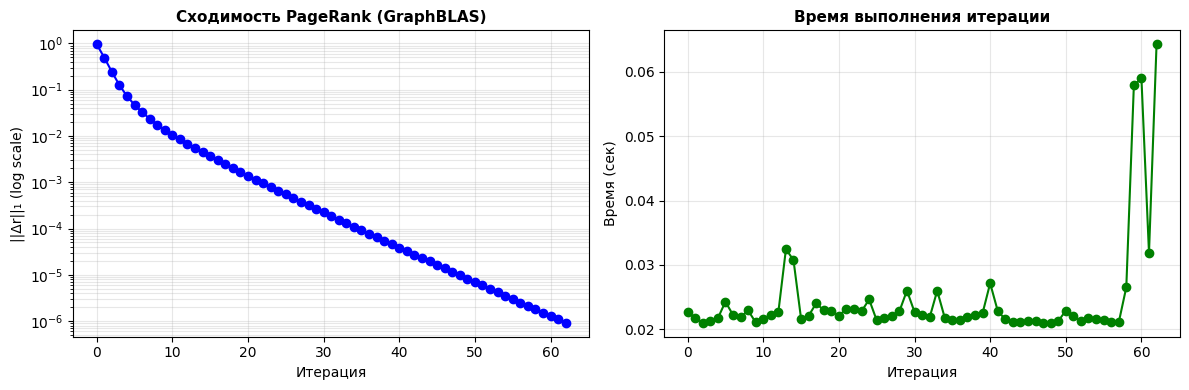

In [9]:
def plot_pagerank_history(history):
    plt.figure(figsize=(12, 4))

    # 1. Сходимость
    plt.subplot(1, 2, 1)
    plt.semilogy(history['rdiff'], 'b-o', linewidth=1.5)
    plt.xlabel('Итерация', fontsize=10)
    plt.ylabel('||Δr||₁ (log scale)', fontsize=10)
    plt.title('Сходимость PageRank (GraphBLAS)', fontsize=11, fontweight='bold')
    plt.grid(True, alpha=0.3, which='both')

    # 2. Время итераций
    plt.subplot(1, 2, 2)
    plt.plot(history['time_per_iter'], 'g-o', linewidth=1.5)
    plt.xlabel('Итерация', fontsize=10)
    plt.ylabel('Время (сек)', fontsize=10)
    plt.title('Время выполнения итерации', fontsize=11, fontweight='bold')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_pagerank_history(result_opt['history'])

Базовая реализация PageRank

In [9]:
def create_stochastic_matrix(A):
    n = A.nrows

    d_out = A.reduce_rowwise(monoid.plus).new()

    inv_d = Vector(dtypes.FP64, n)
    mask = (d_out > 0).new()
    inv_d(mask=mask.S) << binary.truediv(1.0, d_out)

    D = Matrix.diag(inv_d)
    M = D @ A

    return M

In [10]:
def pagerank_basic(A, damping=0.85, max_iter=100, tol=1e-6, verbose=False):
    n = A.nrows
    teleport = (1 - damping) / n

    M = create_stochastic_matrix(A)

    r = Vector(dtypes.FP64, n)
    r[:] << 1.0 / n

    t = Vector(dtypes.FP64, n)
    w = Vector(dtypes.FP64, n)

    history = {
        "rdiff": [],
        "iters": 0,
        "time_per_iter": []}

    for i in range(max_iter):
        start = time.perf_counter()

        t << r

        w << M.T.mxv(t, semiring.plus_times)

        r << binary.times(damping, w)
        r(binary.plus)[:] << teleport

        diff = t.ewise_mult(r, binary.minus).apply(unary.abs)
        rdiff = diff.reduce(monoid.plus).new().value

        iter_time = time.perf_counter() - start

        history["rdiff"].append(rdiff)
        history["time_per_iter"].append(iter_time)
        history["iters"] = i + 1

        if verbose and (i % 10 == 0 or i == 0):
            print(f"Итерация {i:3d}: изменение = {rdiff:.2e}, время = {iter_time*1000:.2f} мс")

        if rdiff < tol:
            if verbose:
                print(f"Сходимость достигнута на итерации {i+1}")
            break

    return r, history

Бенчмаркинг базовой реализации PageRank

In [12]:
result_base = benchmark_pagerank(A_fb, pagerank_basic, name="Базовый PageRank")

hist_base = result_base['history']

Запуск: Базовый PageRank
Итерация   0: изменение = 9.58e-01, время = 67.72 мс
Итерация  10: изменение = 1.06e-02, время = 18.14 мс
Итерация  20: изменение = 1.37e-03, время = 19.26 мс
Итерация  30: изменение = 2.22e-04, время = 18.85 мс
Итерация  40: изменение = 3.87e-05, время = 19.23 мс
Итерация  50: изменение = 6.98e-06, время = 21.19 мс
Итерация  60: изменение = 1.29e-06, время = 33.04 мс
Сходимость достигнута на итерации 63

Результаты:
  Время выполнения: 1.46 сек
  Итераций: 63
  Пиковая память: 326.58 MB


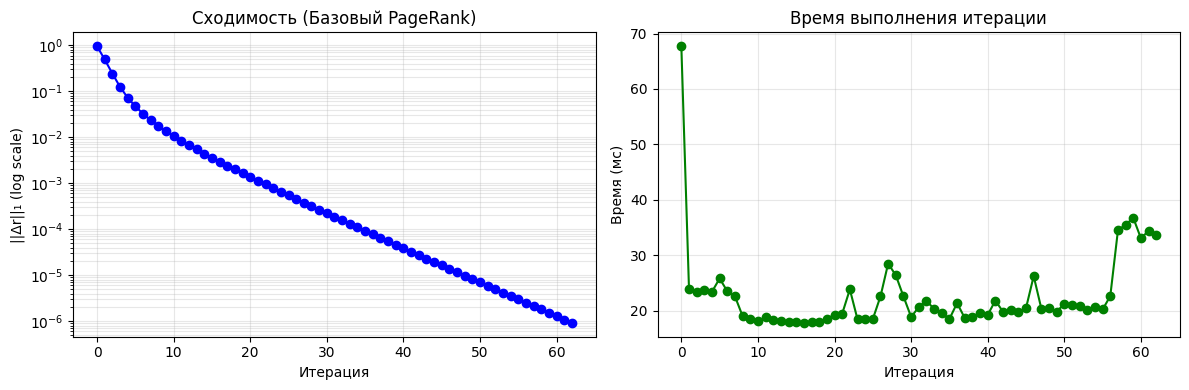

In [13]:
plt.figure(figsize=(12, 4))

# 1. Сходимость
plt.subplot(1, 2, 1)
plt.semilogy(hist_base['rdiff'], 'b-o', linewidth=1.5)
plt.xlabel('Итерация')
plt.ylabel('||Δr||₁ (log scale)')
plt.title('Сходимость (Базовый PageRank)')
plt.grid(True, alpha=0.3, which='both')

# 2. Время итераций
plt.subplot(1, 2, 2)
plt.plot(np.array(hist_base['time_per_iter']) * 1000, 'g-o', linewidth=1.5)
plt.xlabel('Итерация')
plt.ylabel('Время (мс)')
plt.title('Время выполнения итерации')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Сравнение результатов

In [14]:
print("Сравнение реализаций")

hist_base = result_base['history']
r_base = result_base["result"]
r_opt = result_opt["result"]

print("\nИтерации до сходимости:")
print(f"  Базовая реализация: {hist_base['iters']}")
print(f"  Оптимизированная реализация: {result_opt['iters']}")

print("\nВремя выполнения:")
print(f"  Базовая реализация: {result_base['time']:.4f} сек")
print(f"  Оптимизированная реализация: {result_opt['time']:.4f} сек")

print("\nПиковое потребление памяти:")
print(f"  Базовая реализация: {result_base['peak_memory_mb']:.2f} MB")
print(f"  Оптимизированная реализация: {result_opt['peak_memory_mb']:.2f} MB")

r_base_np = np.array([r_base[i].value for i in range(r_base.size)])
r_opt_np = np.array([r_opt[i].value for i in range(r_opt.size)])

max_diff = np.max(np.abs(r_base_np - r_opt_np))
l1_diff = np.sum(np.abs(r_base_np - r_opt_np))
l2_diff = np.linalg.norm(r_base_np - r_opt_np)

print("\nРазница рангов:")
print(f"  Max |Δr|: {max_diff:.6e}")

Сравнение реализаций

Итерации до сходимости:
  Базовая реализация: 63
  Оптимизированная реализация: 63

Время выполнения:
  Базовая реализация: 1.4631 сек
  Оптимизированная реализация: 1.5668 сек

Пиковое потребление памяти:
  Базовая реализация: 326.58 MB
  Оптимизированная реализация: 248.53 MB

Разница рангов:
  Max |Δr|: 1.259342e-06


**Вывод:** Анализируя полученные результаты, можно отметить, что обе реализации показывают сопоставимую сходимость - 63 итерации. Оптимизированная версия PageRank продемонстрировала снижение потребление памяти почти на 25%, однако работает немного медленнее, что может быть связано с дополнительными накладными расходами операций GraphBLAS. Полученная разница в рангах имеет порядок 10⁻⁶, это говорит о хорошей численной устойчивости оптимизированной реализации и практически полном совпадением результатов с базовой реализацией.

#### **Задание 2: Динамический (инкрементальный) PageRank**

Реализуйте функцию быстрого обновления рангов при добавлении новых рёбер без полного пересчёта

In [23]:
def incremental_pagerank(A_old, r_old, new_edges, damping=0.85, max_iter=50, tol=1e-6, verbose=False):
    n = A_old.nrows

    A_new = A_old.dup()

    changed_rows = set()

    delta_A = Matrix(dtypes.FP32, n, n)

    for src, dst in new_edges:
        A_new[src, dst] = 1.0
        delta_A[src, dst] = 1.0
        changed_rows.add(src)

    d_out = A_old.reduce_rowwise(monoid.plus).new()
    d_out_new_part = A_new.reduce_rowwise(monoid.plus).new()

    inv_d = Vector(dtypes.FP32, n)

    # базовое значение
    mask_old = (d_out > 0).new()
    inv_d(mask=mask_old.S) << binary.truediv(1.0, d_out)

    # обновляем только затронутые строки
    for i in changed_rows:
        val = d_out_new_part[i].value
        val = 0.0 if val is None else val

        if val > 0:
            inv_d[i] << 1.0 / val
        else:
            inv_d[i] << 0.0

    delta_r = Vector(dtypes.FP32, n)
    delta_r[:] << 0.0

    t = Vector(dtypes.FP32, n)
    w = Vector(dtypes.FP32, n)

    history = {
        "rdiff": [],
        "time_per_iter": [],
        "iters": 0}

    inv_d_old = Vector(dtypes.FP32, n)
    mask_old = (d_out > 0).new()
    inv_d_old(mask=mask_old.S) << binary.truediv(1.0, d_out)

    w_new = A_new.T.mxv(r_old.ewise_mult(inv_d, binary.times), semiring.plus_times)
    w_old = A_old.T.mxv(r_old.ewise_mult(inv_d_old, binary.times), semiring.plus_times)
    b = damping * (w_new - w_old)

    for i in range(max_iter):
        start = time.perf_counter()

        t << delta_r

        w << A_new.T.mxv(t.ewise_mult(inv_d, binary.times), semiring.plus_times)

        delta_r << damping * w + b

        # сходимость
        diff = (delta_r - t).apply(unary.abs)
        rdiff = diff.reduce(monoid.plus).value
        rdiff = 0.0 if rdiff is None else rdiff

        iter_time = time.perf_counter() - start

        history["rdiff"].append(rdiff)
        history["time_per_iter"].append(iter_time)
        history["iters"] = i + 1

        if verbose:
            print(f"Итерация {i:3d}: изменение = {rdiff:.2e}, время = {iter_time*1000:.2f} мс")

        if rdiff < tol:
            if verbose:
                print(f"[Сходимость достигнута на итерации {i+1}]")
            break

    r_new = r_old.dup()
    r_new << r_new + delta_r

    # нормализация
    s = r_new.reduce(monoid.plus).value
    s = 0.0 if s is None else s
    if s > 0:
        r_new << r_new / s

    return r_new, history

Тест

In [18]:
print("Полный PageRank на исходном графе")

tracemalloc.start()
start = time.perf_counter()

r_full, hist_full = pagerank_basic(A_fb, verbose=False)

time_full = time.perf_counter() - start
_, peak_full = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Время: {time_full:.4f} сек")
print(f"Итераций: {hist_full['iters']}")
print(f"Память: {peak_full / 1024**2:.2f} MB")

Полный PageRank на исходном графе
Время: 1.5547 сек
Итераций: 63
Память: 261.98 MB


In [19]:
# Добавление 100 случайных рёбер
n = A_fb.nrows
num_new_edges = 100

new_edges = [
    (random.randint(0, n-1), random.randint(0, n-1))
    for _ in range(num_new_edges)]

A_new = A_fb.dup()
for u, v in new_edges:
    A_new[u, v] = 1.0

In [20]:
print("Incremental PageRank")

tracemalloc.start()
start = time.perf_counter()

r_incr, hist_incr = incremental_pagerank(A_fb, r_full, new_edges, verbose=False)

time_incr = time.perf_counter() - start
_, peak_incr = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Время: {time_incr:.4f} сек")
print(f"Итераций: {hist_incr['iters']}")
print(f"Память: {peak_incr / 1024**2:.2f} MB")

Incremental PageRank
Время: 0.9239 сек
Итераций: 27
Память: 285.78 MB


In [21]:
print("Полный PageRank на обновлённом графе")

tracemalloc.start()
start = time.perf_counter()

r_full_new, hist_full_new = pagerank_basic(A_new, verbose=False)

time_full_new = time.perf_counter() - start
_, peak_full_new = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Время: {time_full_new:.4f} сек")
print(f"Итераций: {hist_full_new['iters']}")
print(f"Память: {peak_full_new / 1024**2:.2f} MB")

Полный PageRank на обновлённом графе
Время: 1.8027 сек
Итераций: 63
Память: 303.29 MB


In [22]:
print("Сравнение результатов")

print("\nВремя выполнения:")

print(f"Full PageRank (исходный граф): {time_full:.4f} сек")
print(f"Incremental PageRank: {time_incr:.4f} сек")
print(f"Full PageRank (новый граф): {time_full_new:.4f} сек")

print("\nКоличество итераций:")

print(f"Full PageRank (исходный граф): {hist_full['iters']}")
print(f"Incremental PageRank: {hist_incr['iters']}")
print(f"Full PageRank (новый граф): {hist_full_new['iters']}")

print("\nПотребление памяти:")

print(f"Full PageRank (исходный граф): {peak_full / 1024**2:.2f} MB")
print(f"Incremental PageRank: {peak_incr / 1024**2:.2f} MB")
print(f"Full PageRank (новый граф): {peak_full_new / 1024**2:.2f} MB")

r_incr_np = np.array([r_incr[i].value for i in range(r_incr.size)])
r_full_new_np = np.array([r_full_new[i].value for i in range(r_full_new.size)])

max_diff = np.max(np.abs(r_incr_np - r_full_new_np))

print("\nРазница рангов:")
print(f"max(|r_incr - r_full_new|) = {max_diff:.6e}")

Сравнение результатов

Время выполнения:
Full PageRank (исходный граф): 1.5547 сек
Incremental PageRank: 0.9239 сек
Full PageRank (новый граф): 1.8027 сек

Количество итераций:
Full PageRank (исходный граф): 63
Incremental PageRank: 27
Full PageRank (новый граф): 63

Потребление памяти:
Full PageRank (исходный граф): 261.98 MB
Incremental PageRank: 285.78 MB
Full PageRank (новый граф): 303.29 MB

Разница рангов:
max(|r_incr - r_full_new|) = 2.700174e-05


**Вывод:** Полученные результаты демонстрируют, что полный PageRank на исходном графе выполнился за 1.55 сек и потребовал 63 итерации при пиковом потреблении памяти 261.98 MB. Полный пересчёт на обновлённом графе занял 1.8 сек и также потребовал 63 итерации, при этом потребление памяти повысилось и составило 303.29 MB, в то время как инкрементальный алгоритм отработал быстрее, за 0.92 сек, и потребовал 27 итераций, но использовал немного больше памяти (285.78 MB), что связано с хранением промежуточных структур и вычислением поправок. Это подтверждает, что при небольших изменениях графа инкрементальный подход обеспечивает более эффективное обновление PageRank по времени при сохранении высокой точности результатов.